Train data shape: (891, 12)
Test data shape: (418, 11)

Train data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Train data description:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean  

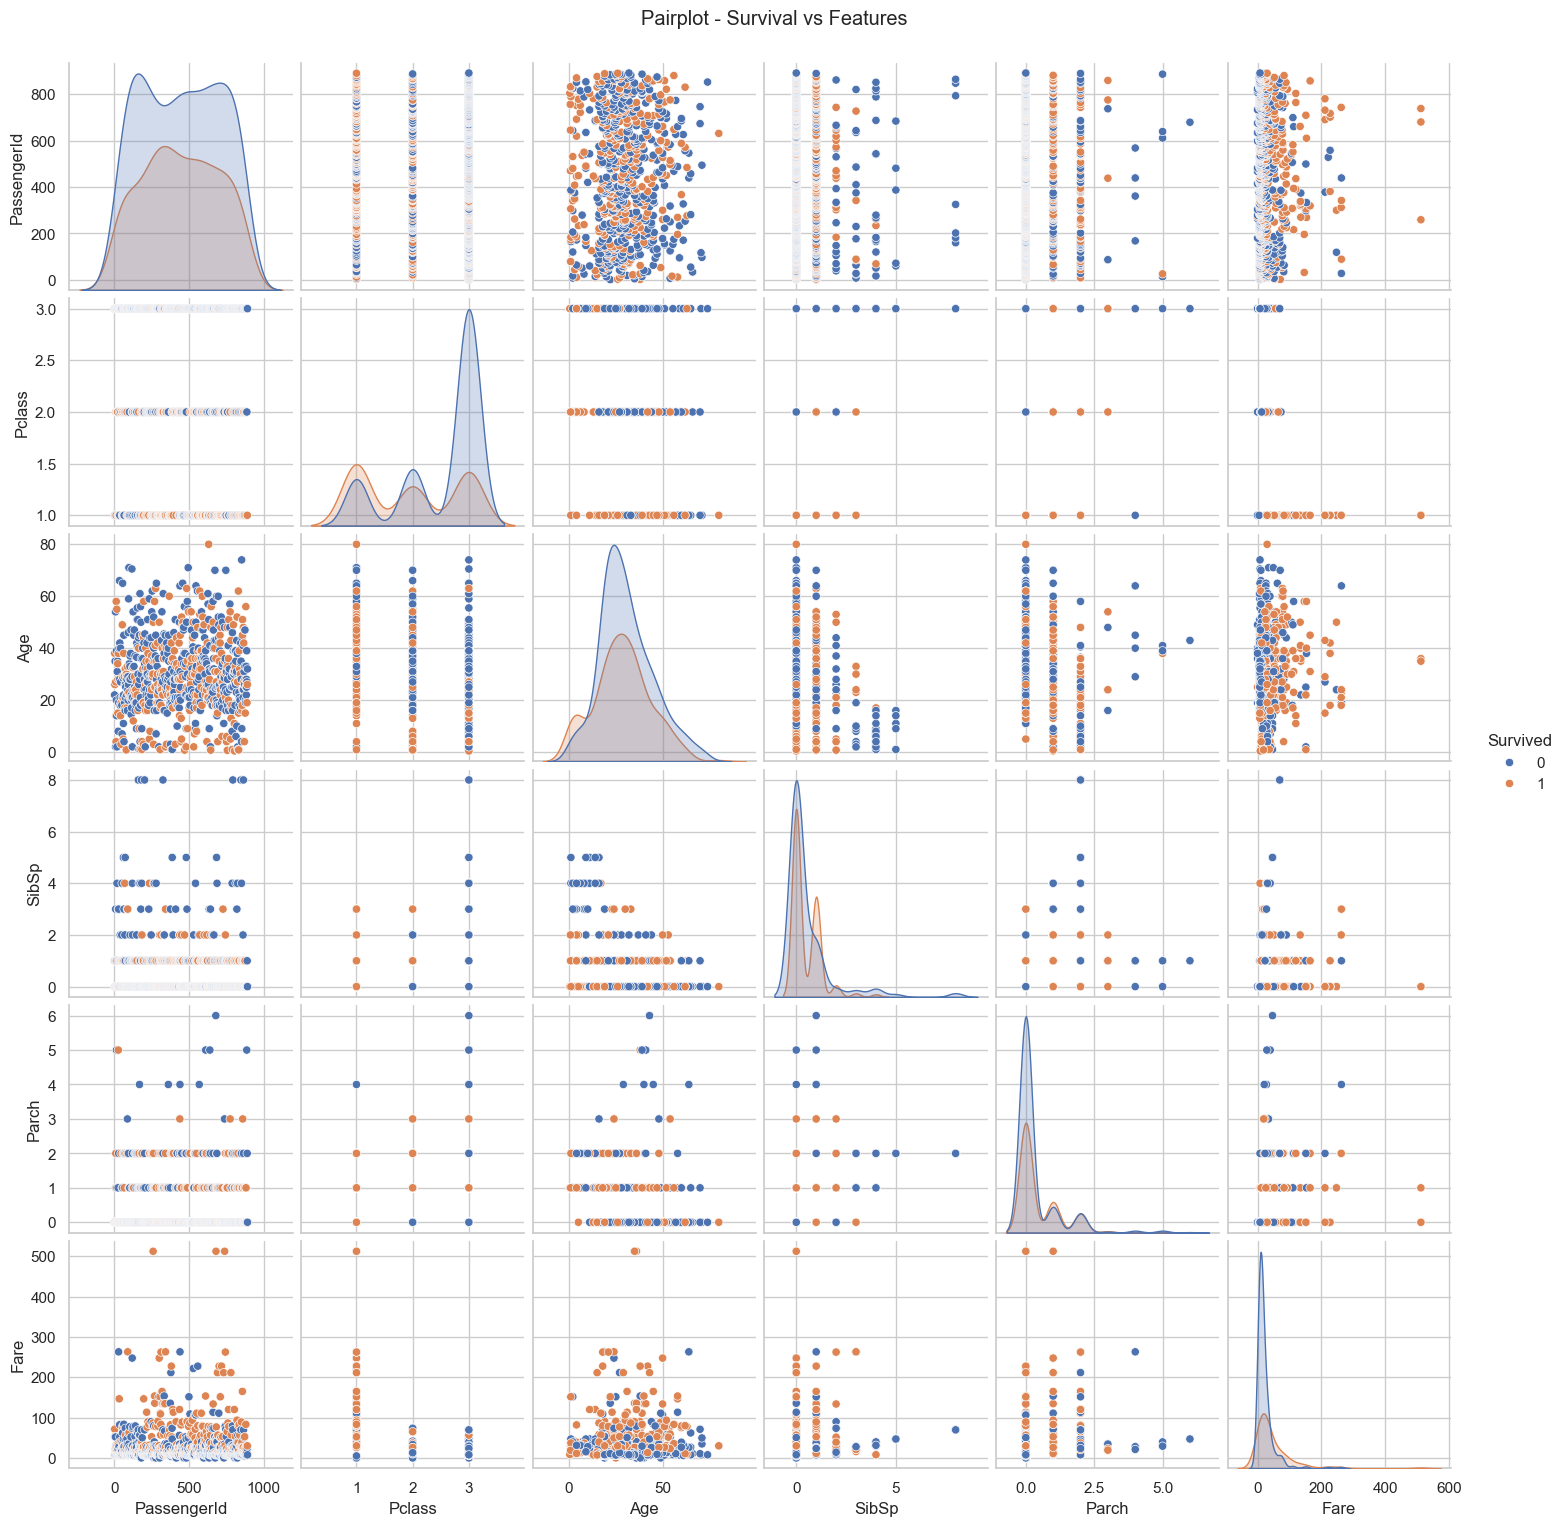

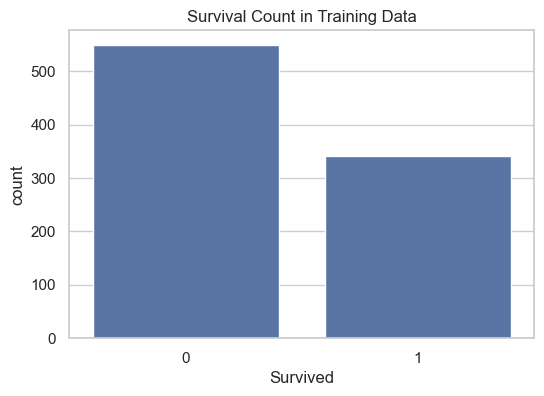

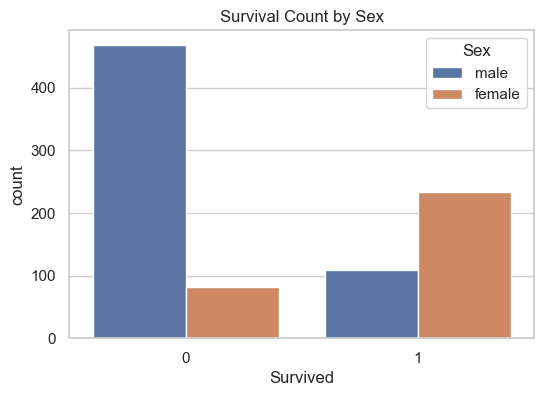

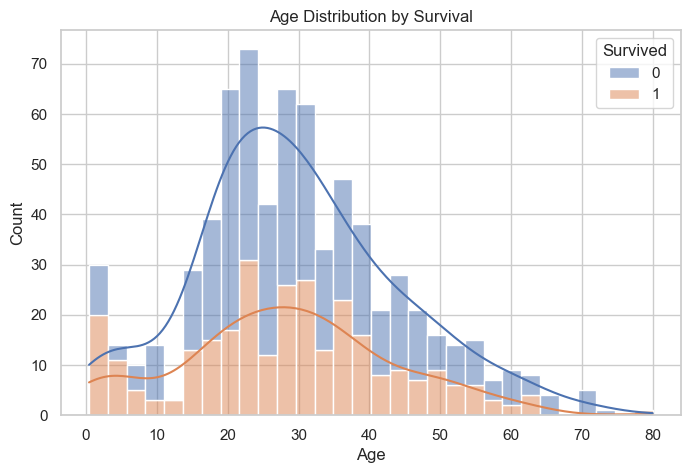

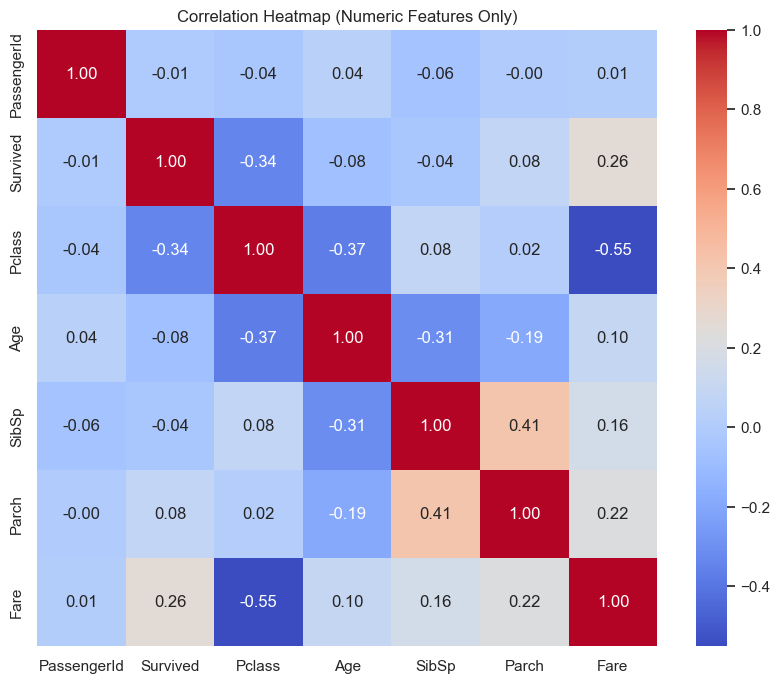


Observation: 'Sex' negatively correlates with survival (male=1, female=0), indicating females survived more.

Decision Tree Performance:
Accuracy : 0.7821
Precision: 0.7215
Recall   : 0.7703
F1-Score : 0.7451

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       105
           1       0.72      0.77      0.75        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.78      0.78       179


Random Forest Performance:
Accuracy : 0.8212
Precision: 0.8088
Recall   : 0.7432
F1-Score : 0.7746

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82

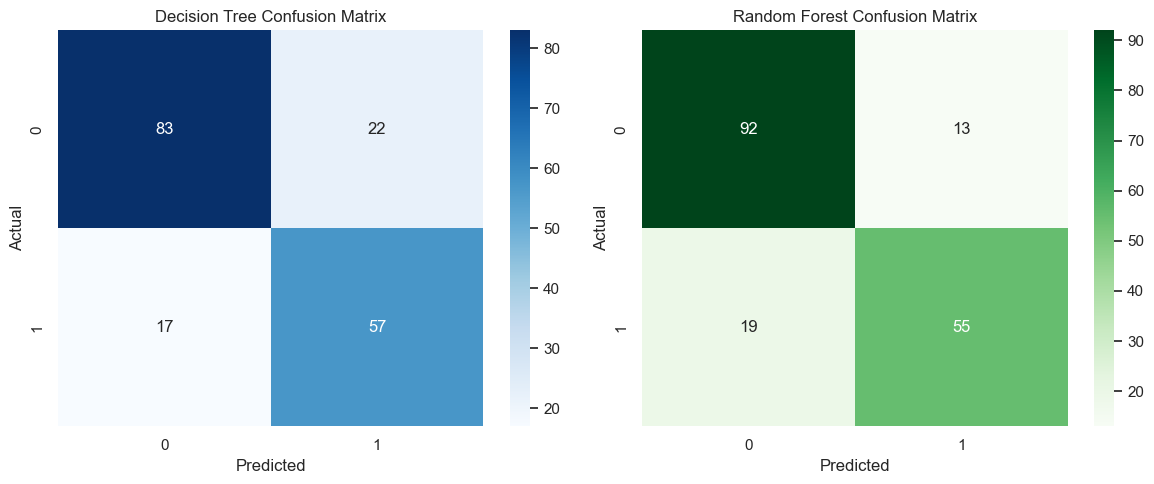


Insight: Random Forest outperforms Decision Tree, benefiting from ensemble learning and reduced overfitting.

Random Forest 5-Fold Cross-Validation Accuracy: 0.8092
Before, I let the tree grow really deep (max_depth: None, 10, 20), which made the model super good on training (~94% accuracy).
but not so great on validation (~82%) — classic overfitting.
So, I used smaller depths (3 and 5) to keep trees simple and help the model learn better patterns that improved generalization!

Best Parameters from Grid Search: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}

Tuned Random Forest Performance:
Accuracy : 0.8156
Precision: 0.8361
Recall   : 0.6892
F1-Score : 0.7556

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.84      0.69      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg      

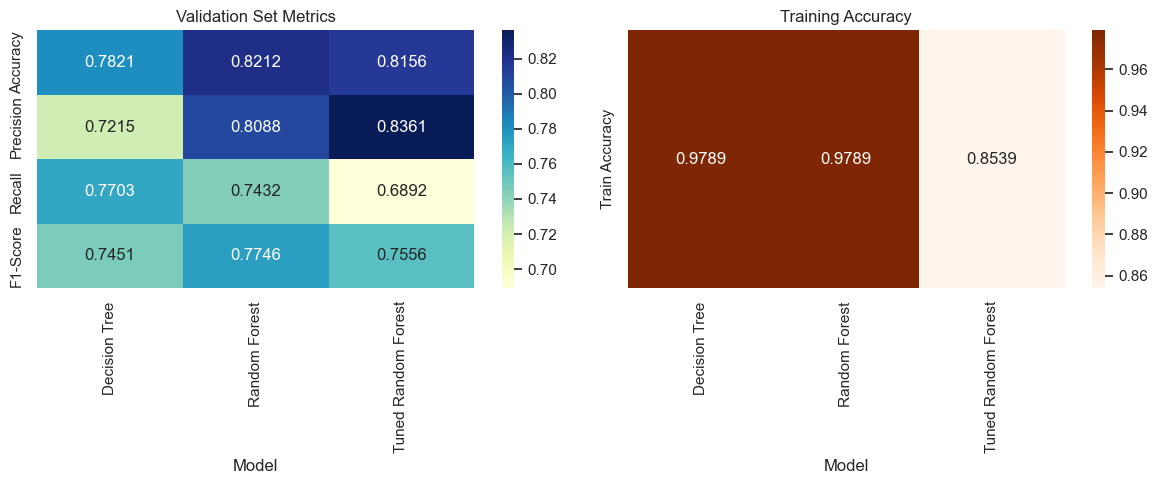


Here Tuned Random Forest Generalized Better Than Other Model


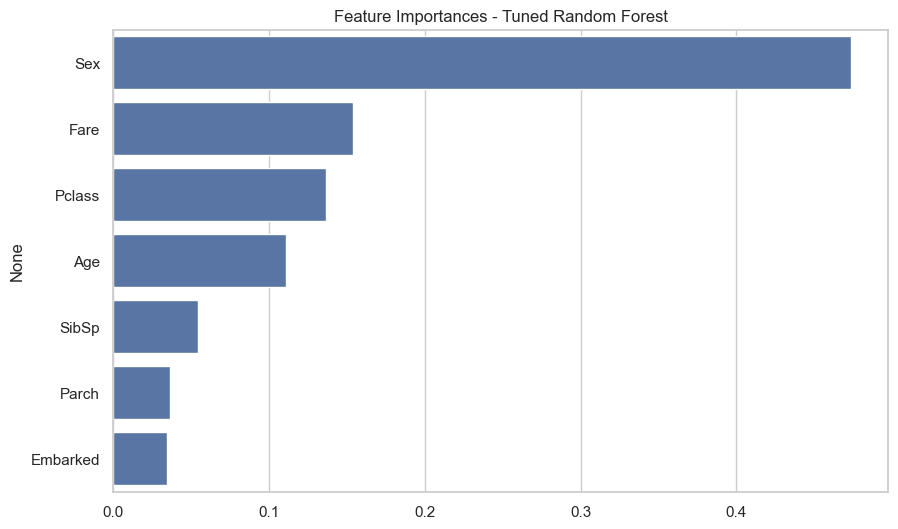

Top features influencing survival: 'Sex', 'Fare', and 'Age' dominate.

Test Predictions:
    PassengerId  Survived
0           892         0
1           893         0
2           894         0
3           895         0
4           896         0
5           897         0
6           898         1
7           899         0
8           900         1
9           901         0
10          902         0
11          903         0
12          904         1
13          905         0
14          906         1
15          907         1
16          908         0
17          909         0
18          910         0
19          911         1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

sns.set_theme(style="whitegrid")  # for better visualization style

# Load Data
train_path = "C:\\Users\\Min\\Desktop\\BI Lab\\Lab 2\\titanic_train.csv"
test_path = "C:\\Users\\Min\\Desktop\\BI Lab\\Lab 2\\titanic_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Train data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}\n")

# Initial Exploration
print("Train data info:")
train_df.info()
print("\nTrain data description:")
print(train_df.describe())

print("\nMissing values in train data:\n", train_df.isnull().sum())
print("\nMissing values in test data:\n", test_df.isnull().sum())

# Survival rate by Sex
survival_rates = train_df.groupby('Sex')['Survived'].mean() * 100
print("\nSurvival rates by Sex (%):")
for sex, rate in survival_rates.items():
    print(f"{sex.capitalize()}: {rate:.2f}%")

# Exploratory Data Analysis (EDA)

# To Visualize pairplot
sns.pairplot(train_df, hue='Survived')
plt.suptitle("Pairplot - Survival vs Features", y=1.02)
plt.show()

# To Show the Survival Count in Training Data
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=train_df)
plt.title('Survival Count in Training Data')
plt.show()

# Survival count by sex
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', hue='Sex', data=train_df)
plt.title('Survival Count by Sex')
plt.show()

# Age distribution by survival
plt.figure(figsize=(8,5))
sns.histplot(data=train_df, x='Age', hue='Survived', bins=30, kde=True, multiple='stack')
plt.title('Age Distribution by Survival')
plt.show()

# Correlation heatmap (numeric features only)
plt.figure(figsize=(10,8))
sns.heatmap(train_df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()

print("\nObservation: 'Sex' negatively correlates with survival (male=1, female=0), indicating females survived more.")

# Data Preprocessing
# Combine Train and Test for Consistent Preprocessing
train_df['TrainSplit'] = 1
test_df['TrainSplit'] = 0
test_df['Survived'] = np.nan  # add dummy target

full_data = pd.concat([train_df, test_df], sort=False)

# Feature Engineering
# To Fill missing Age and Fare with median
full_data['Age'] = full_data['Age'].fillna(full_data['Age'].median())
full_data['Fare'] = full_data['Fare'].fillna(full_data['Fare'].median())

# To Fill Embarked with most frequent
full_data['Embarked'] = full_data['Embarked'].fillna(full_data['Embarked'].mode()[0])

# To Drop Cabin and Ticket (too many missing or not informative)
full_data.drop(['Cabin', 'Ticket', 'Name', 'PassengerId'], axis=1, inplace=True)

full_data.head()

# To Convert categorical variables to numeric
le = LabelEncoder()
full_data['Sex'] = le.fit_transform(full_data['Sex'])
full_data['Embarked'] = le.fit_transform(full_data['Embarked'])

# Separate Back into Train and Test
train = full_data[full_data['TrainSplit'] == 1].drop(['TrainSplit'], axis=1)
test = full_data[full_data['TrainSplit'] == 0].drop(['Survived', 'TrainSplit'], axis=1)

X = train.drop(['Survived'], axis=1)
y = train['Survived'].astype(int)

# To Split training set into train/validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training and Evaluation
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Performance:")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score : {f1_score(y_true, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

# Decision Tree
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
dt_val_preds = dt_clf.predict(X_val)
evaluate_model("Decision Tree", y_val, dt_val_preds)

# Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
rf_val_preds = rf_clf.predict(X_val)
evaluate_model("Random Forest", y_val, rf_val_preds)

# To Visualize Confusion Matrices
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_val, dt_val_preds), annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_val, rf_val_preds), annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

print("\nInsight: Random Forest outperforms Decision Tree, benefiting from ensemble learning and reduced overfitting.")

# Cross-validation
cv_scores = cross_val_score(rf_clf, X, y, cv=5)
print(f"\nRandom Forest 5-Fold Cross-Validation Accuracy: {cv_scores.mean():.4f}")

# Hyperparameter Tuning for Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5]
}

print("Before, I let the tree grow really deep (max_depth: None, 10, 20), which made the model super good on training (~94% accuracy).\n"
      "but not so great on validation (~82%) — classic overfitting.\n"
      "So, I used smaller depths (3 and 5) to keep trees simple and help the model learn better patterns that improved generalization!")

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3)
grid_search.fit(X_train, y_train)

print("\nBest Parameters from Grid Search:", grid_search.best_params_)

best_rf = grid_search.best_estimator_

best_rf_val_preds = best_rf.predict(X_val)
evaluate_model("Tuned Random Forest", y_val, best_rf_val_preds)

# Model Comparison

# Calculate training predictions and accuracy
dt_train_preds = dt_clf.predict(X_train)
rf_train_preds = rf_clf.predict(X_train)
best_rf_train_preds = best_rf.predict(X_train)

# Get training accuracy
dt_train_acc = accuracy_score(y_train, dt_train_preds)
rf_train_acc = accuracy_score(y_train, rf_train_preds)
best_rf_train_acc = accuracy_score(y_train, best_rf_train_preds)

# Re-run evaluations with metrics collected
def get_metrics(name, y_true, y_pred, train_acc):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "Train Accuracy": train_acc
    }

model_metrics = [
    get_metrics("Decision Tree", y_val, dt_val_preds, dt_train_acc),
    get_metrics("Random Forest", y_val, rf_val_preds, rf_train_acc),
    get_metrics("Tuned Random Forest", y_val, best_rf_val_preds, best_rf_train_acc)
]

summary_df = pd.DataFrame(model_metrics)
print("\nModel Comparison Summary with Training Accuracy:")
print(summary_df)

# Heatmap visualization: validation metrics + training accuracy side by side
plt.figure(figsize=(12, 5))

# Validation metrics heatmap
plt.subplot(1, 2, 1)
sns.heatmap(summary_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].T,
            annot=True, cmap='YlGnBu', fmt=".4f")
plt.title("Validation Set Metrics")

# Training accuracy heatmap
plt.subplot(1, 2, 2)
sns.heatmap(summary_df.set_index('Model')[['Train Accuracy']].T,
            annot=True, cmap='Oranges', fmt=".4f")
plt.title("Training Accuracy")

plt.tight_layout()
plt.show()

print("\nHere Tuned Random Forest Generalized Better Than Other Model")

# Feature Importance
importances = best_rf.feature_importances_
feature_names = X.columns
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=importances[sorted_idx], y=feature_names[sorted_idx])
plt.title("Feature Importances - Tuned Random Forest")
plt.show()

print("Top features influencing survival: 'Sex', 'Fare', and 'Age' dominate.")

# Predict on Test Data and Show Predictions
test_preds = best_rf.predict(test)

test_passenger_ids = pd.read_csv(test_path)['PassengerId']

test_predictions_df = pd.DataFrame({
    "PassengerId": test_passenger_ids,
    "Survived": test_preds
})

print("\nTest Predictions:")
print(test_predictions_df.head(20))  # Show first 20 predictions


